<a href="https://colab.research.google.com/github/marynatarasevych/ML_Study/blob/main/Tarasevych_%22HW_2_3_%D0%94%D0%B5%D1%80%D0%B5%D0%B2%D0%B0_%D0%BF%D1%80%D0%B8%D0%B9%D0%BD%D1%8F%D1%82%D1%82%D1%8F_%D1%80%D1%96%D1%88%D0%B5%D0%BD%D1%8C_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



https://github.com/marynatarasevych/ML_Study/blob/main/process_bank_churn.py

In [7]:
!wget -q https://raw.githubusercontent.com/marynatarasevych/ML_Study/refs/heads/main/process_bank_churn.py

In [1]:
from process_bank_churn import preprocess_data

**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib
import os
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import plot_tree, export_text
from sklearn.metrics import roc_curve, auc
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
raw_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Data kaggle/Train Data.csv")

In [5]:
#preprocess_data
result = preprocess_data(
    raw_df,
    target='Exited',
    cols_to_drop_name=['id', 'CustomerId', 'Surname'],
    scaler_numeric=False
)

X_train = result['X_train']
train_targets = result['train_targets']
X_val = result['X_val']
val_targets = result['val_targets']
input_cols = result['input_cols']
scaler = result['scaler']
encoder = result['encoder']

In [6]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, train_targets)
train_preds = model.predict(X_train)
train_probs = model.predict_proba(X_train)
model.score(X_val, val_targets)

0.8416

In [7]:
train_targets.unique()

array([0., 1.])

In [8]:
from typing import Any
def compute_auroc_and_build_roc(model: Any, inputs, targets, name: str = '') -> float:
    """
    Вычисляет AUROC для заданной модели и данных, строит ROC-кривую.

    Args:
        model: обученная модель с методом predict_proba (например, DecisionTreeClassifier).
        inputs: признаки (X_train, X_val и т.п.).
        targets: истинные значения таргета.
        name: подпись для графика и вывода (например, 'Train', 'Validation', 'Decision Tree').

    Returns:
        Значение AUROC (float).
    """
    # Predict probabilities
    y_pred_proba = model.predict_proba(inputs)[:, 1]

    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # Compute AUROC
    roc_auc = auc(fpr, tpr)
    print(f'AUROC for {name}: {roc_auc:.6f}')

    # Plot the ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
    plt.legend(loc="lower right")
    plt.show()

    return roc_auc

AUROC for Training: 1.000000


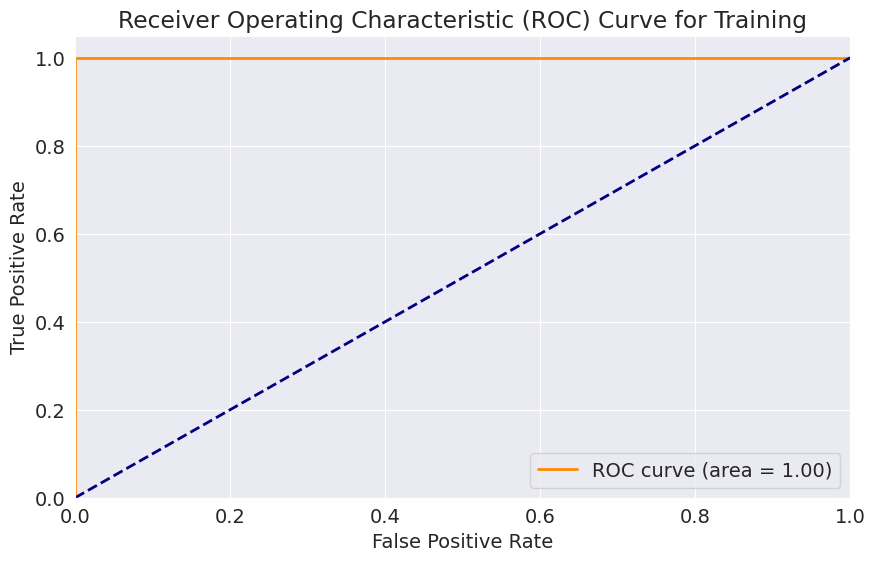

AUROC for Validation: 0.766392


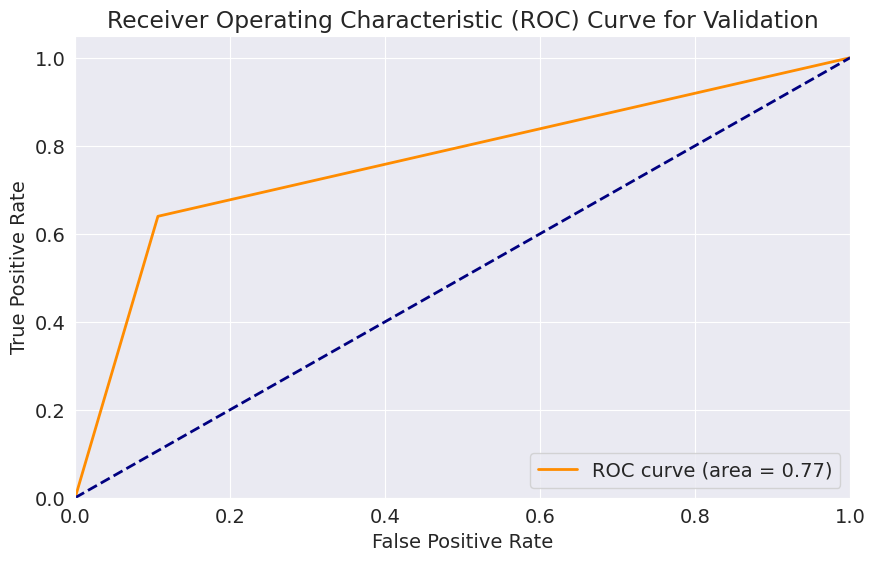

np.float64(0.7663922431892505)

In [9]:
compute_auroc_and_build_roc(model,  X_train, train_targets, 'Training')
compute_auroc_and_build_roc(model, X_val, val_targets, 'Validation')

**Результат**

Модель перенавчена. AUROC на тренувальних данних = 1.0, тобто модель повністю вивчила тренувальні дані. AUROC на валідаційних данних = 0.77

In [10]:
model.tree_.max_depth

25

**Результат**

Глибина дерева - 25

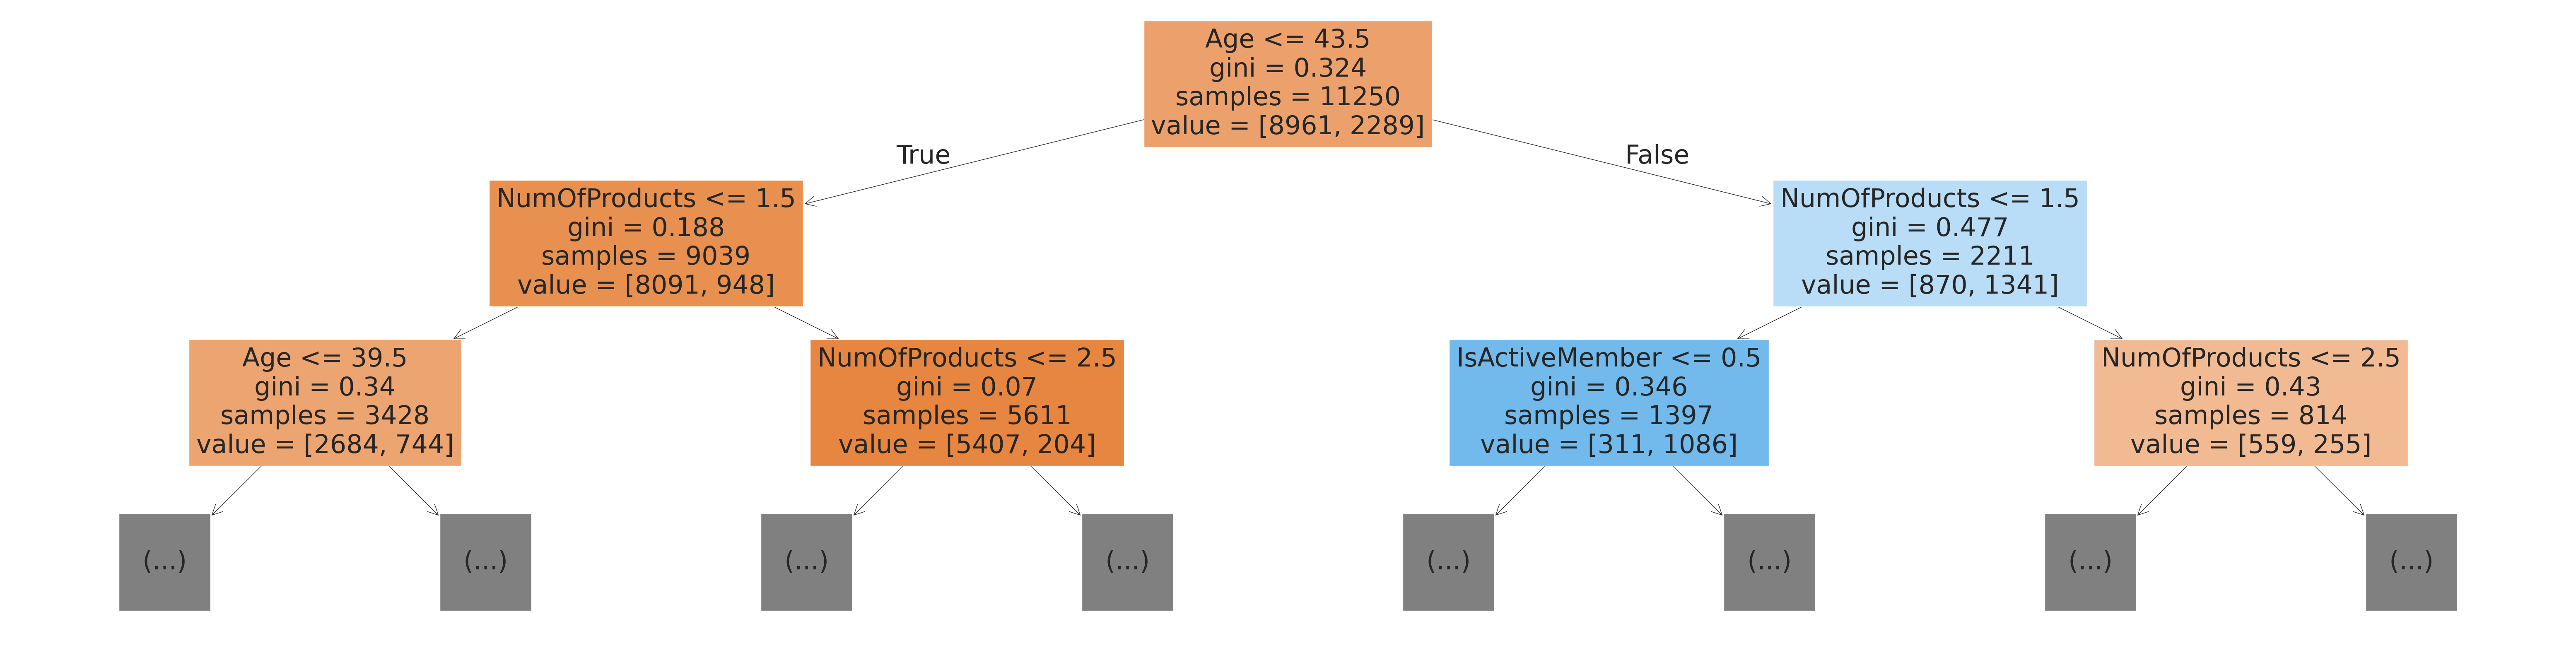

In [11]:
plt.figure(figsize=(80,20))
plot_tree(model, feature_names=X_train.columns, max_depth=2, filled=True);

**Результат**

Найважливіші ознаки, які видні в дереві - Age та NumOfProducts

In [12]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
importance_df.head(10)

,feature,importance
1,Age,0.345619
4,NumOfProducts,0.167947
7,EstimatedSalary,0.132232
0,CreditScore,0.114144
3,Balance,0.081396
2,Tenure,0.062382
6,IsActiveMember,0.033667
5,HasCrCard,0.013662
9,Geography_Germany,0.009946
15,Gender_Male,0.009182


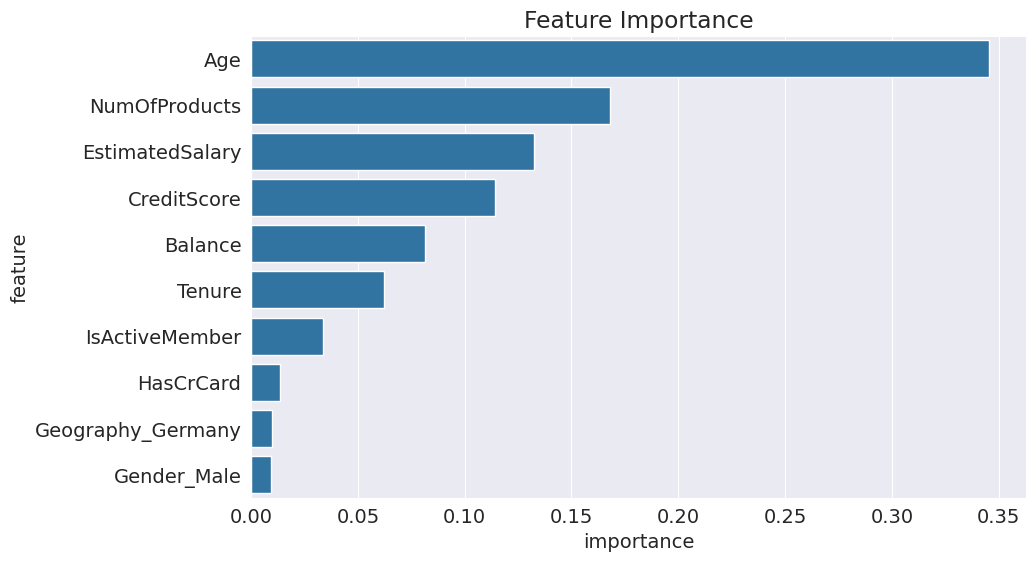

In [13]:
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature');

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

AUROC for Training: 0.929885


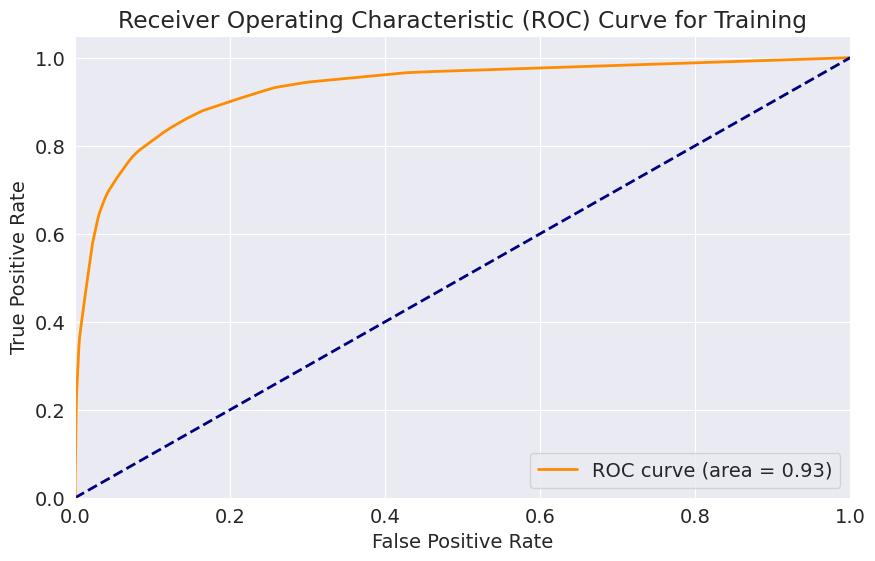

AUROC for Validation: 0.924656


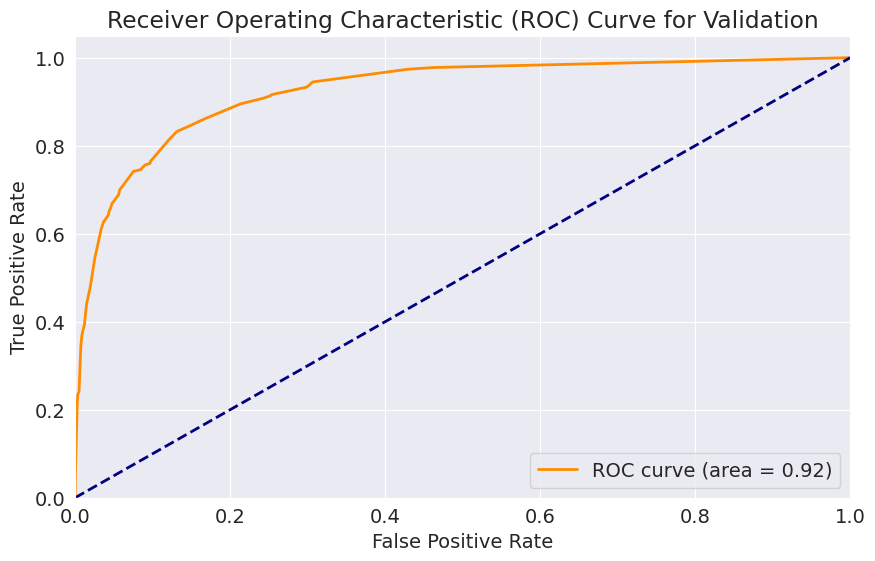

np.float64(0.9246555958300736)

In [44]:
model_max_7_41 = DecisionTreeClassifier(max_depth=7, max_leaf_nodes=41, random_state=42) #0.924656
model_max_7_41.fit(X_train, train_targets)
compute_auroc_and_build_roc(model_max_7_41,  X_train, train_targets, 'Training')
compute_auroc_and_build_roc(model_max_7_41, X_val, val_targets, 'Validation')

**Результат**

Найкраща модель з підбором руками - max_depth=7, max_leaf_nodes=41.

AUROC for Validation: 0.924656

**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [50]:
def max_depth(md):
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(X_train, train_targets)
    train_auc = roc_auc_score(train_targets, model.predict_proba(X_train)[:, 1])
    val_auc = roc_auc_score(val_targets, model.predict_proba(X_val)[:, 1])
    return {
        'Max Depth': md,
        'Training AUROC': train_auc,
        'Validation AUROC': val_auc,
    }

max_depth_values = range(1, 21)

auc_df = pd.DataFrame([
    max_depth_leaf_auc(md)
    for md in max_depth_values
])

auc_df.sort_values('Validation AUROC', ascending=False).head(20)

,Max Depth,Training AUROC,Validation AUROC
4,5,0.925483,0.919912
6,7,0.942308,0.915584
5,6,0.934095,0.915471
3,4,0.910752,0.912550
7,8,0.950853,0.902363
2,3,0.896683,0.893916
8,9,0.961022,0.868615
1,2,0.841958,0.848759
9,10,0.970247,0.848322
10,11,0.979150,0.837362


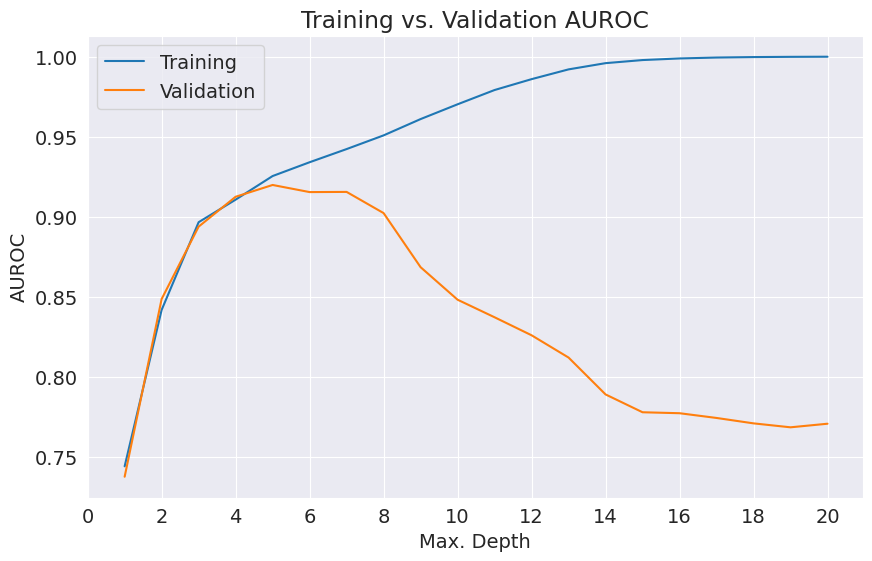

In [49]:
plt.figure()
plt.plot(auc_df['Max Depth'], auc_df['Training AUROC'])
plt.plot(auc_df['Max Depth'], auc_df['Validation AUROC'])
plt.title('Training vs. Validation AUROC')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('AUROC')
plt.legend(['Training', 'Validation']);

**Результат**

Найкраща модель при max_depth=5, Validation AUROC = 0.919912.

При ручному підборі я використовувала також max_leaf_nodes. Спробую підбором параметрів знайти найкращу комбінацію max_depth та max_leaf_nodes

In [41]:
def max_depth_leaf_auc(md, mln):
    model = DecisionTreeClassifier(max_depth=md, max_leaf_nodes=mln, random_state=42)
    model.fit(X_train, train_targets)
    train_auc = roc_auc_score(train_targets, model.predict_proba(X_train)[:, 1])
    val_auc = roc_auc_score(val_targets, model.predict_proba(X_val)[:, 1])
    return {
        'Max Depth': md,
        'Max Leaf Nodes': mln,
        'Training AUROC': train_auc,
        'Validation AUROC': val_auc,
    }

max_depth_values = range(1, 21)
max_leaf_nodes_values = list(range(2, 101))  # каждое значение от 2 до 100, а не через шаг

auc_df = pd.DataFrame([
    max_depth_leaf_auc(md, mln)
    for md in max_depth_values
    for mln in max_leaf_nodes_values
])

auc_df.sort_values('Validation AUROC', ascending=False).head(10)

,Max Depth,Max Leaf Nodes,Training AUROC,Validation AUROC
736,8,45,0.930379,0.924879
735,8,44,0.930317,0.924813
738,8,47,0.930679,0.924718
734,8,43,0.930217,0.924714
737,8,46,0.930457,0.924707
633,7,41,0.929885,0.924656
636,7,44,0.930296,0.924535
635,7,43,0.930082,0.924525
634,7,42,0.929996,0.924457
743,8,52,0.931623,0.923615


**Результат**

Найкраща модель при max_depth=8 та max_leaf_nodes=45, Validation AUROC = 0.924879, що трохи краще за підібрану мною руками.

Тренуємо окрему модуль з цими параметрами:

AUROC for Training: 0.930379


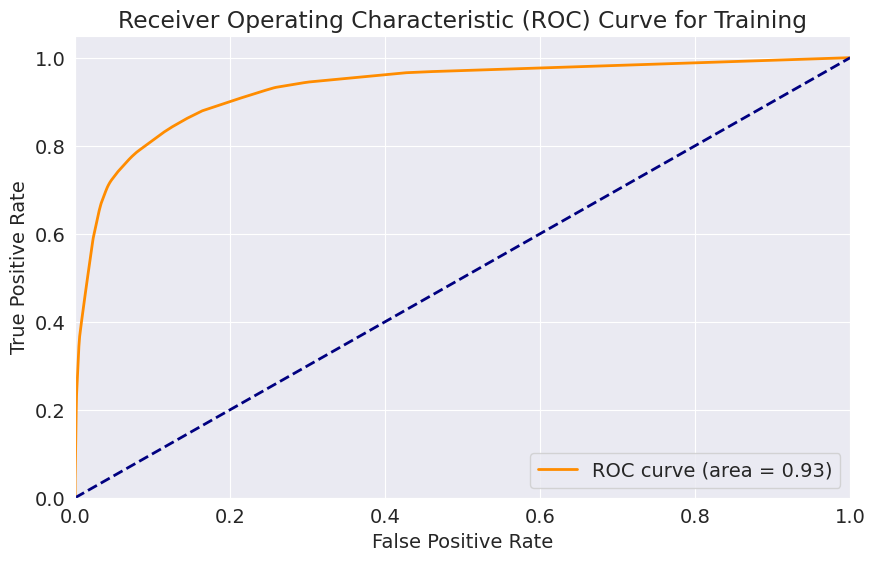

AUROC for Validation: 0.924879


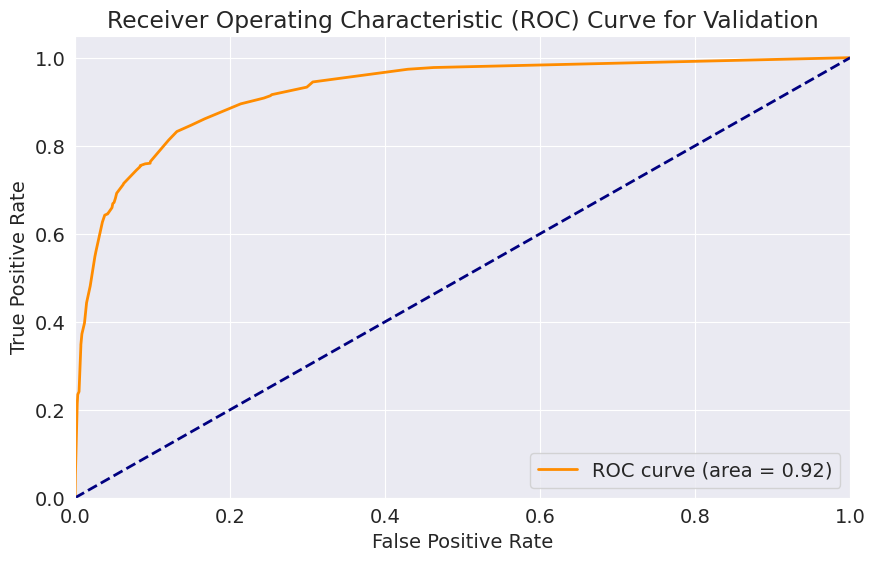

np.float64(0.924878712077368)

In [51]:
model_max_8_45 = DecisionTreeClassifier(max_depth=8, max_leaf_nodes=45, random_state=42)
model_max_8_45.fit(X_train, train_targets)
compute_auroc_and_build_roc(model_max_8_45,  X_train, train_targets, 'Training')
compute_auroc_and_build_roc(model_max_8_45, X_val, val_targets, 'Validation')

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [52]:
from process_bank_churn import preprocess_new_data

In [53]:
test_raw_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Data kaggle/Test Data.csv")

In [54]:
X_test = preprocess_new_data(
    test_raw_df,
    input_cols=result['input_cols'],
    scaler=result['scaler'],
    encoder=result['encoder'],
    imputer_cat=result['imputer_cat'],
    imputer_num=result['imputer_num'],
)
X_test.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Male,Geography_France,Geography_Germany,Geography_Spain,Gender_Male
0,584.0,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
1,551.0,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
2,706.0,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
3,717.0,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0
4,592.0,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0


In [57]:
test_preds_proba = model_max_8_45.predict_proba(X_test)[:, 1]

In [58]:
sample_submission = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Data kaggle/Sample Submission.csv")

In [60]:
sample_submission['Exited'] = test_preds_proba
sample_submission

,id,Exited
0,15000,0.058824
1,15001,0.014736
2,15002,0.014736
3,15003,0.759434
4,15004,0.014736
...,...,...
9995,24995,0.014736
9996,24996,0.014736
9997,24997,0.014736
9998,24998,0.041061


In [61]:
sample_submission.to_csv('/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/ДЗ/Модуль 2.2 Логістична регресія/Data kaggle/submission_log_reg.csv', index=False)

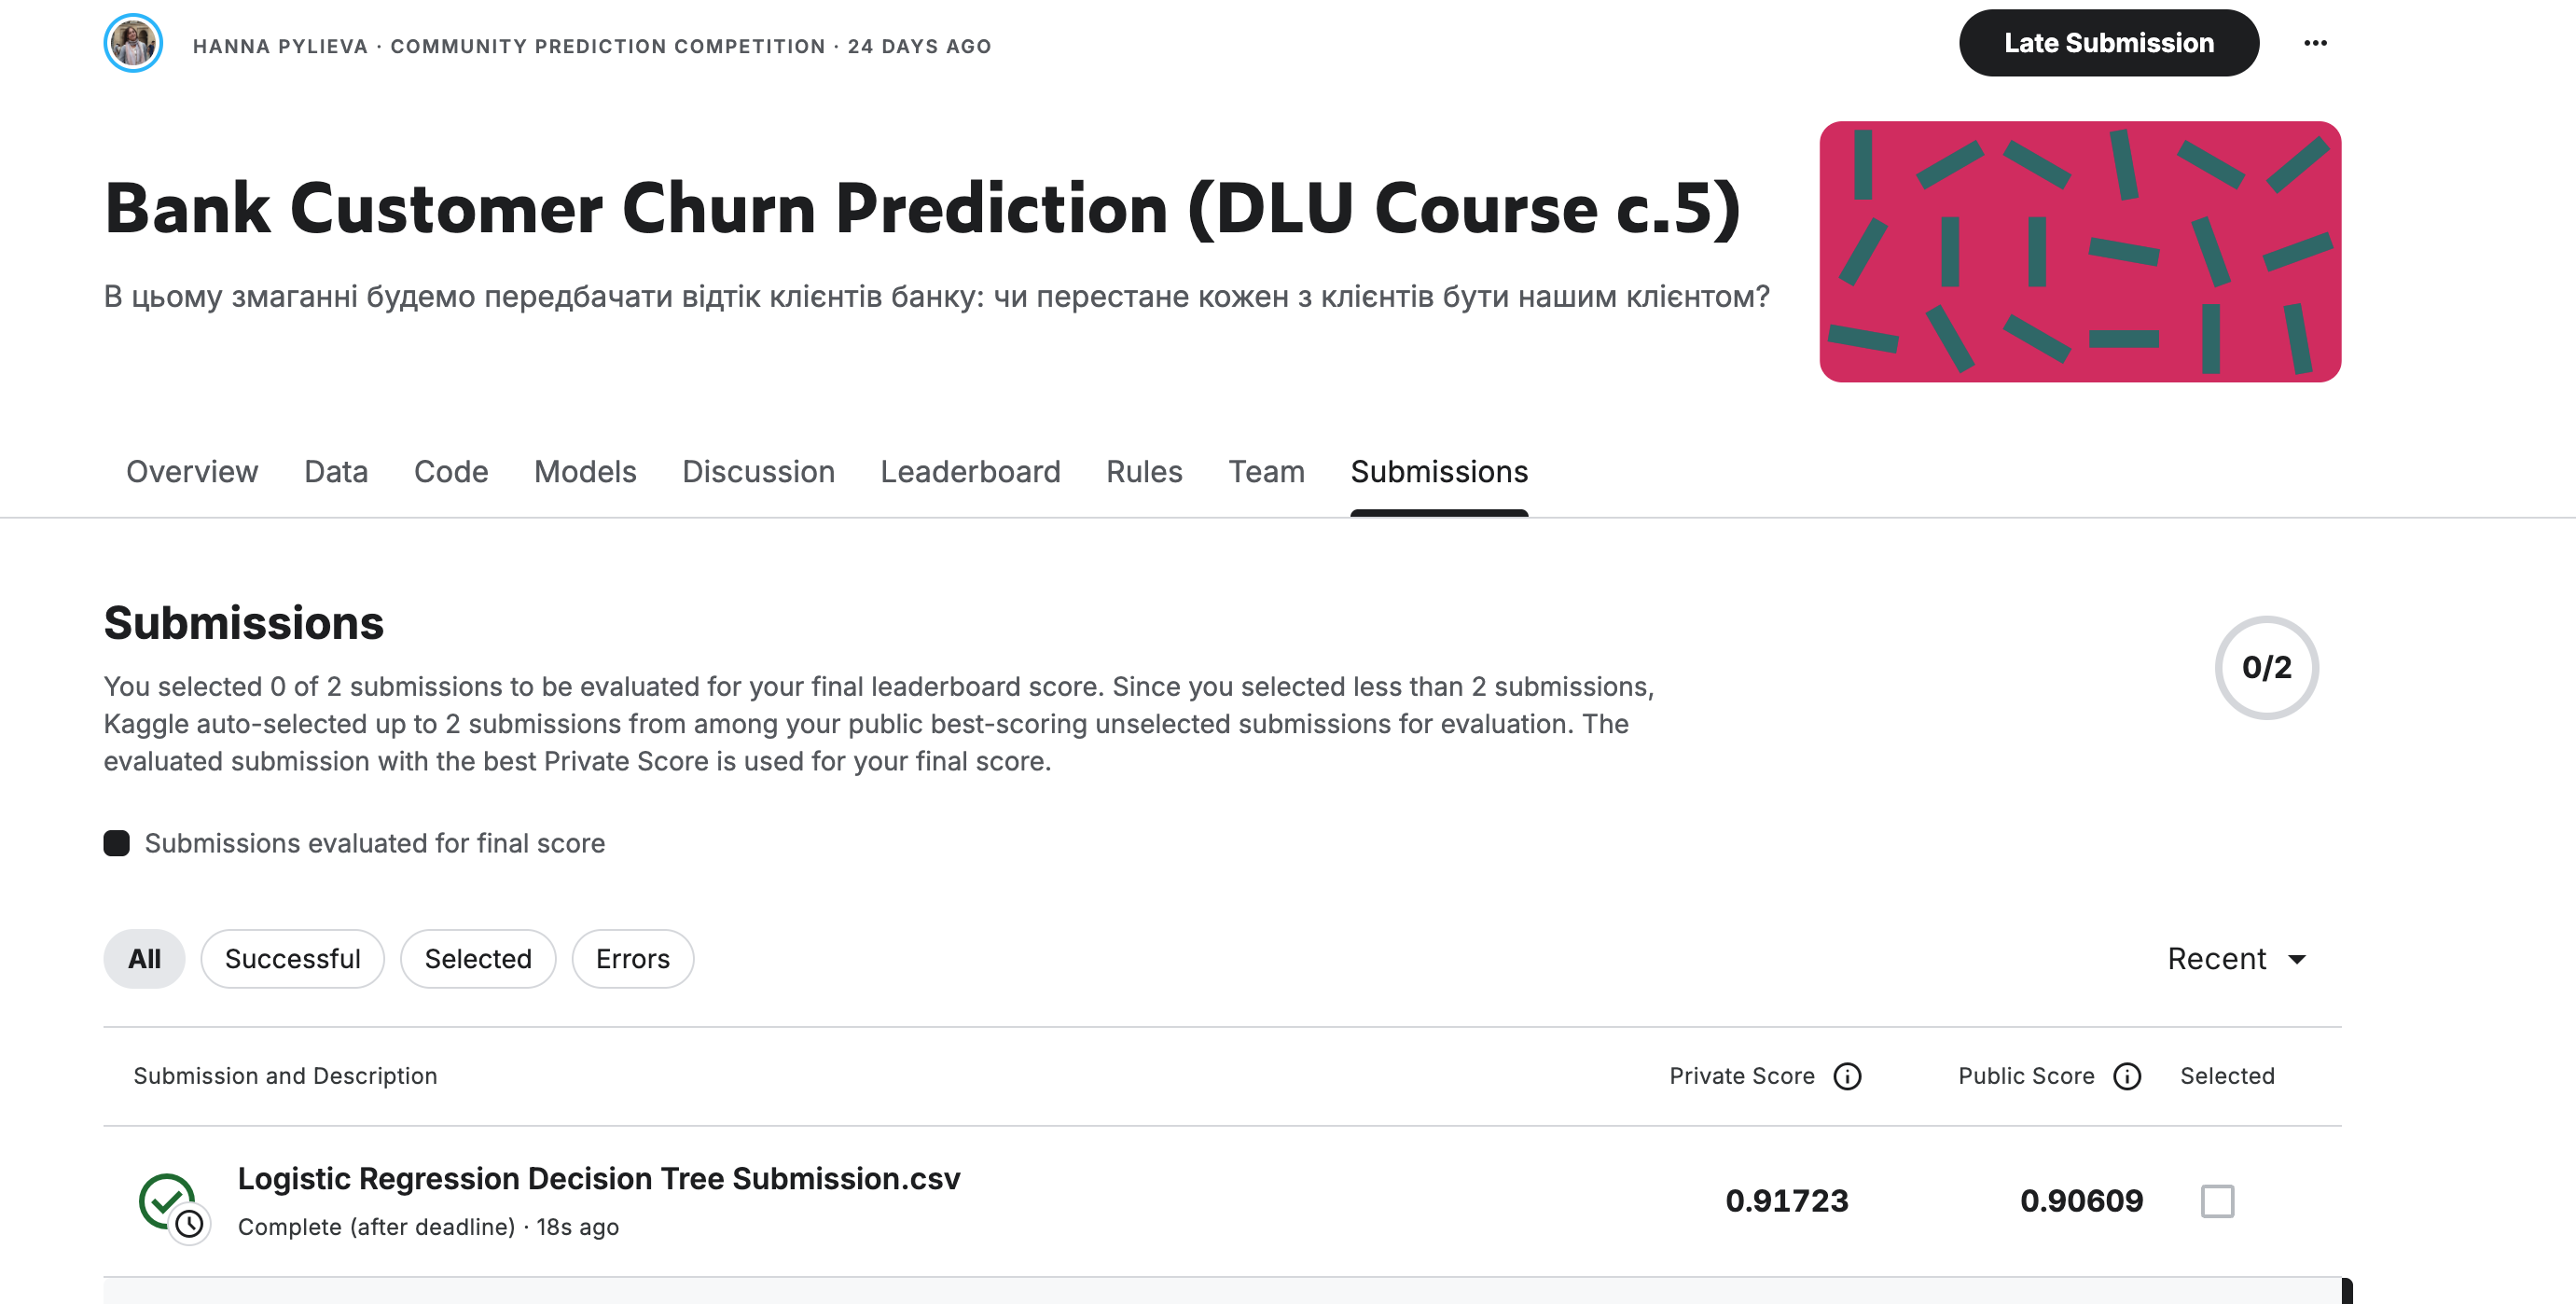